In [1]:
import pickle

with open("buowset1.1_efficientnet_b1_ATTEMPT_TO_STUDY_NEW_DATA.pkl", mode="rb") as f:
        data = pickle.load(f)


In [2]:
import datasets

In [3]:
data["audio"][0]

{'bytes': None,
 'path': '/mnt/restorage/Audiomoth/Raw sound files/2024/RGCB/AB10/B032/20240524-0607_032_continuous/20240524_000000.WAV',
 'offset': 0,
 'duration': 3}

In [4]:
len(data["audio"])

2717590

In [5]:
data["pred"].shape

(2717590, 6)

In [6]:
import numpy as np
from tqdm import tqdm
from scipy.special import softmax

In [7]:
from IPython.display import Audio
import librosa
from tqdm import tqdm

  0%|          | 0/2717590 [00:00<?, ?it/s]

/20240524_000000.WAV 	 339 		 alarm


  0%|          | 114/2717590 [00:07<47:50:00, 15.78it/s]

/20240524_000000.WAV 	 639 		 coocoo


  0%|          | 214/2717590 [00:07<22:45:47, 33.16it/s]

...

/20240524_000000.WAV 	 8832 		 coocoo


/20240524_000000.WAV 	 8841 		 coocoo


/20240524_000000.WAV 	 8847 		 coocoo


  0%|          | 2949/2717590 [00:32<8:24:40, 89.65it/s] 


KeyboardInterrupt: Interrupted by user

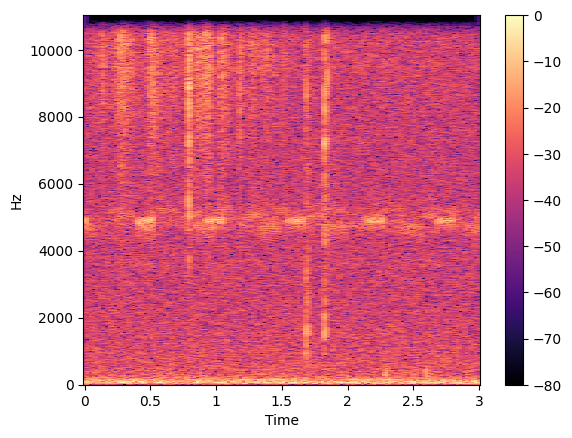

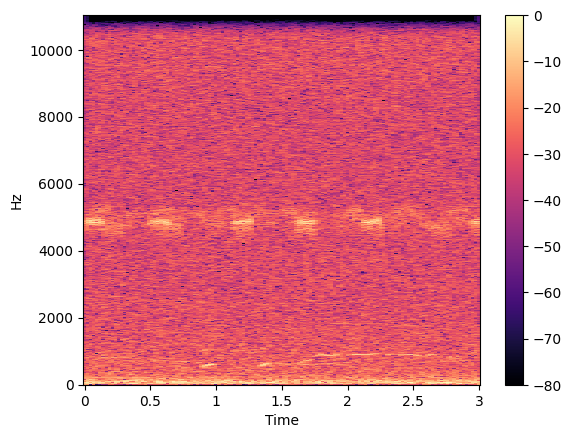

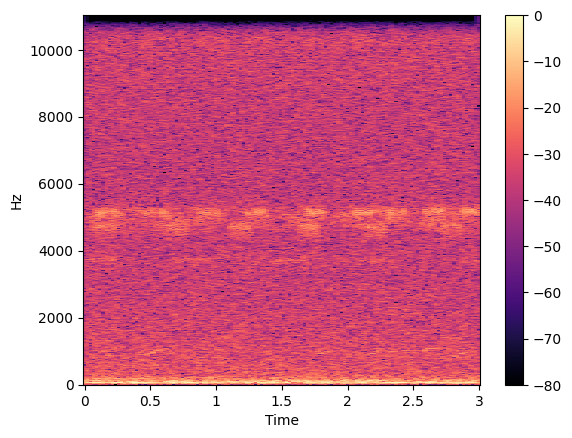

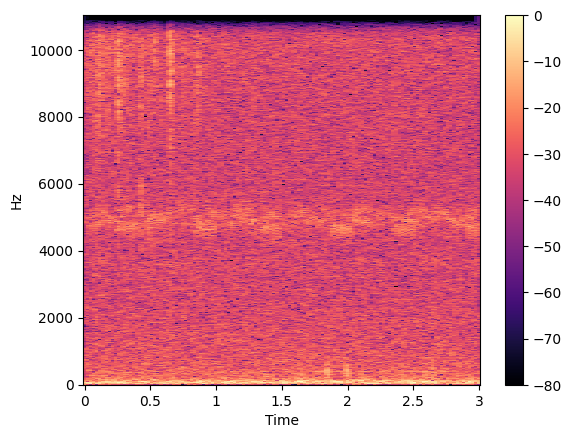

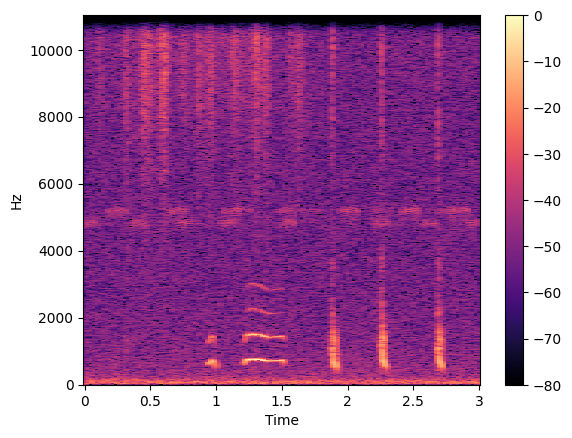

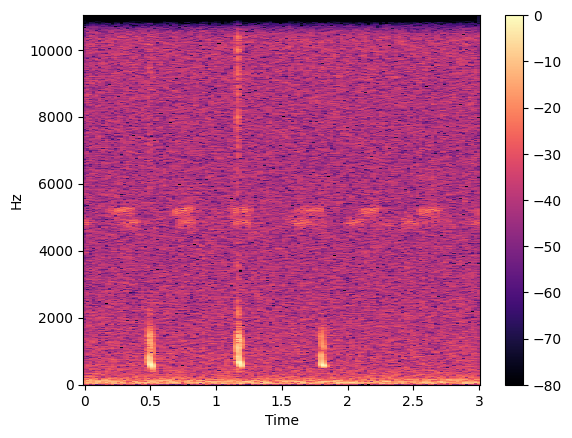

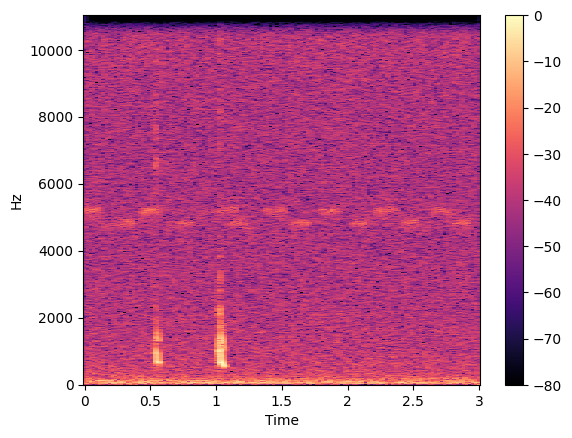

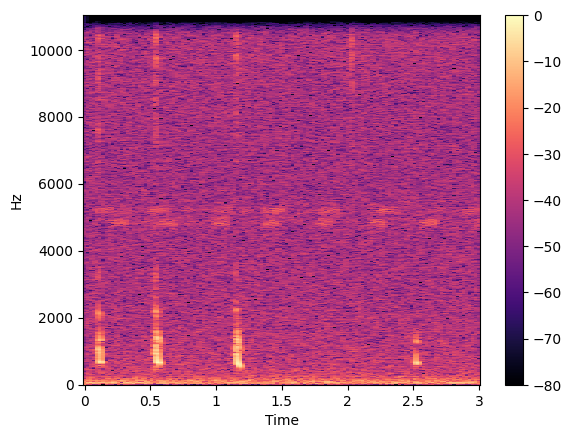

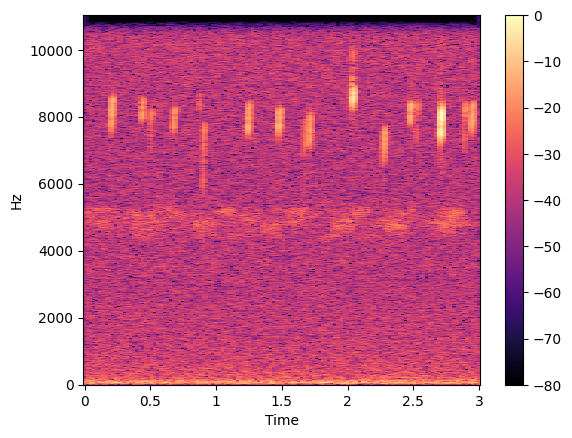

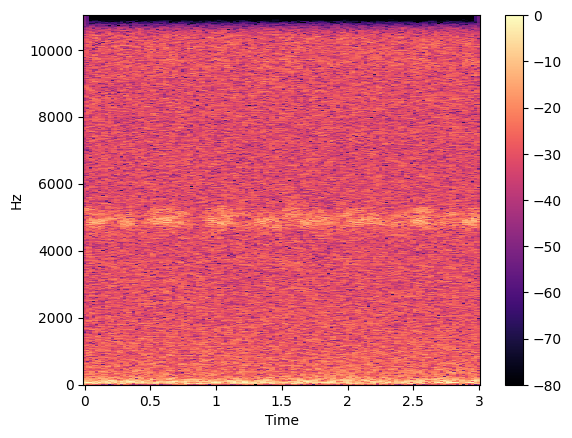

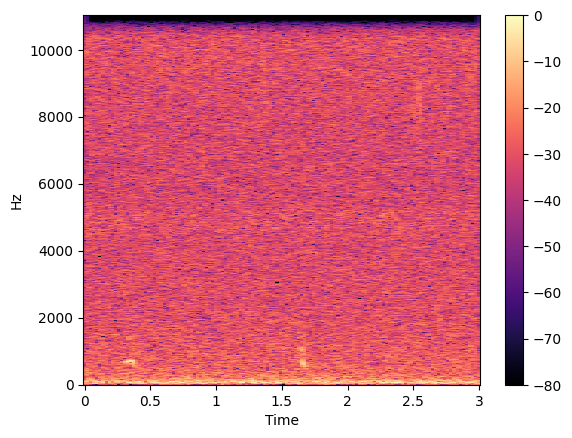

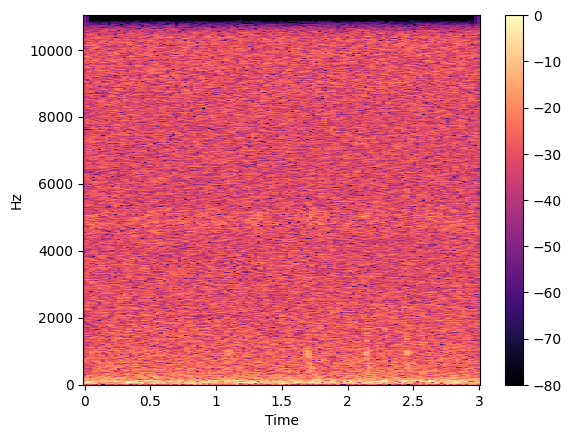

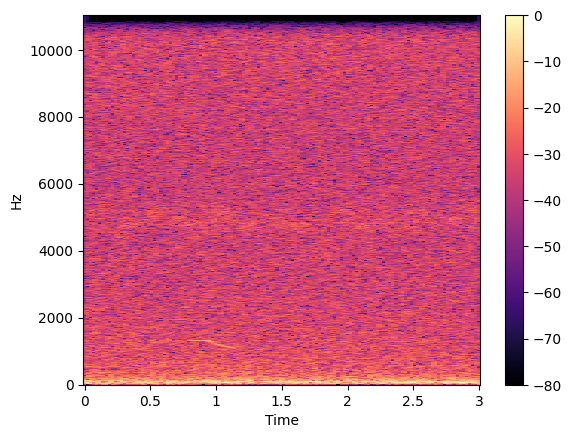

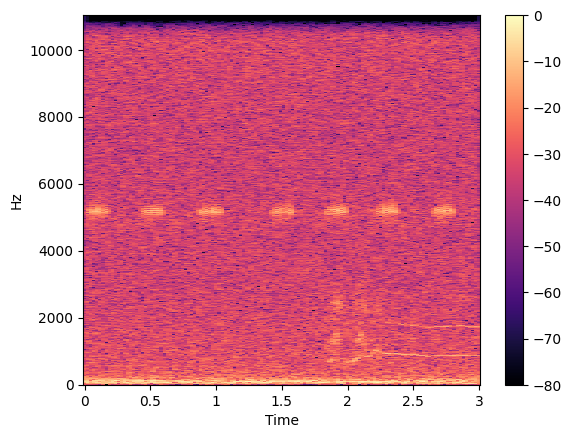

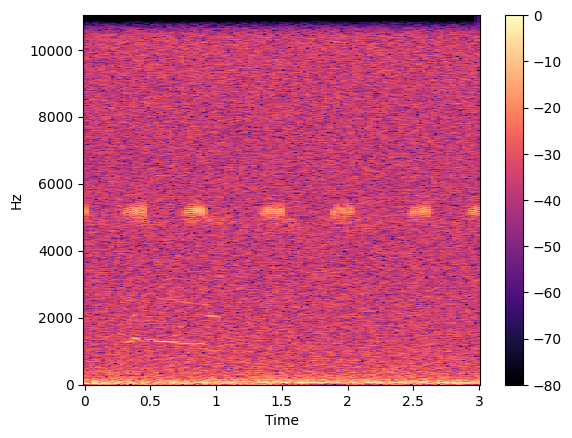

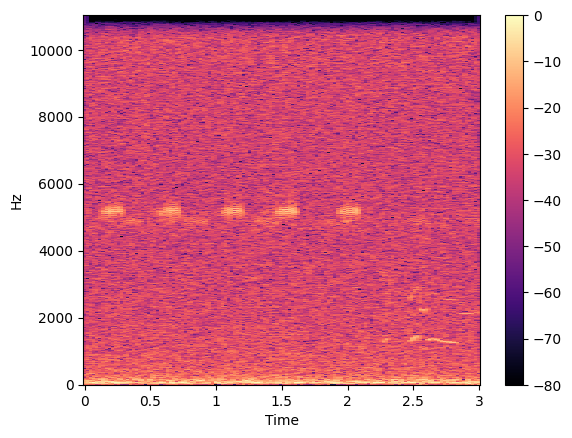

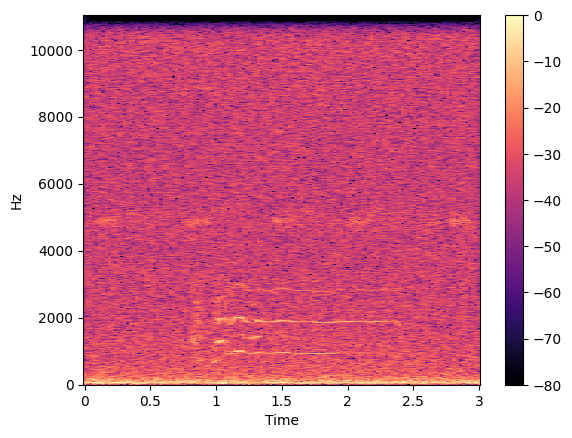

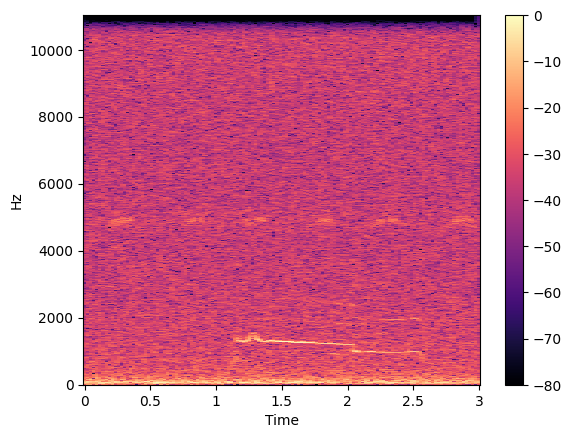

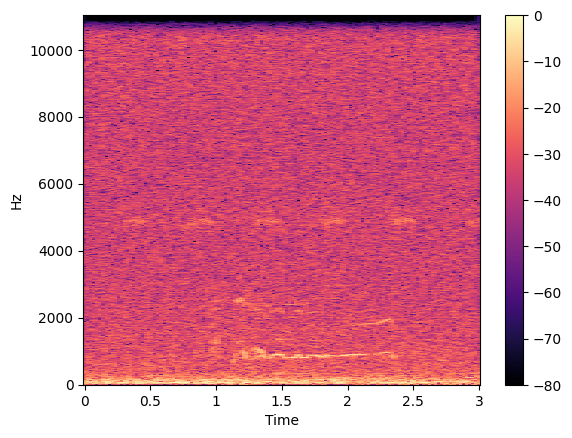

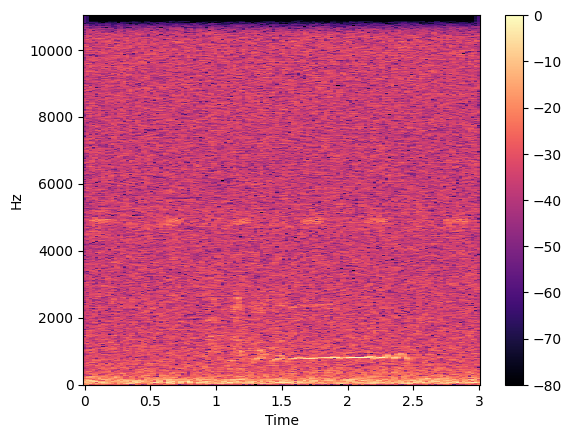

In [8]:
class_list = ["cluck", "coocoo", "twitter", "alarm", "chick begging", "no_buow"]

import matplotlib.pyplot as plt




inferance_out = {
    "file_path": [],
    "offset": [],
    "confidence": [],
    "pred_label": []
}

for i in tqdm(range(len(data["audio"]))):
    file_meta = data["audio"][i]
    
    if np.argmax(data["pred"][i]) == 5:
        continue

    inferance_out["file_path"].append(file_meta["path"])
    inferance_out["offset"].append(file_meta["offset"])

    pred_index = np.argmax(data["pred"][i])
    inferance_out["pred_label"].append(class_list[pred_index])
    inferance_out["confidence"].append(
        softmax(data["pred"][i])[pred_index]
    )

    y, sr = librosa.load(path=file_meta["path"], offset=file_meta["offset"], duration=3)
    display(Audio(data=y, rate=sr))
    
    fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

    img = librosa.display.specshow(D, y_axis='linear', x_axis='time',

                                sr=sr, ax=ax)
    fig.colorbar(img, ax=ax)
    fig.savefig(f"data/burrowing_owl_dataset/img/{file_meta["path"][-20:]}_{file_meta["offset"]}_spec.jpg")


    print(
        file_meta["path"][-20:],
        "\t", file_meta["offset"], "\t"
        "\t", class_list[np.argmax(data["pred"][i])],
        )
    input()

In [ ]:
for key in inferance_out.keys():
    print(len(inferance_out[key]))




    

224691
224691
224691
224691


In [ ]:
class_list = ["cluck", "coocoo", "twitter", "alarm", "chick begging", "no_buow"]

import matplotlib.pyplot as plt




inferance_out = {
    "file_path": [],
    "offset": [],
    "confidence": [],
    "pred_label": [],
    "cluck": [],
    "coocoo": [],
    "twitter": [],
    "alarm":  [],
    "chick_begging": []

}

for i in tqdm(range(len(data["audio"]))):
    file_meta = data["audio"][i]
    
    if np.argmax(data["pred"][i]) == 5:
        continue

    inferance_out["file_path"].append(file_meta["path"])
    inferance_out["offset"].append(file_meta["offset"])

    pred_index = np.argmax(data["pred"][i])
    inferance_out["pred_label"].append(class_list[pred_index])
    inferance_out["confidence"].append(
        softmax(data["pred"][i])[pred_index]
    )

    # print(
    #     file_meta["path"][-20:],
    #     "\t", file_meta["offset"], "\t"
    #     "\t", class_list[np.argmax(data["pred"][i])],
    #     )
    # input()

100%|██████████| 2717590/2717590 [00:07<00:00, 342765.02it/s]


In [11]:
import pandas as pd

df = pd.DataFrame(inferance_out)

In [12]:
df

,file_path,offset,confidence,pred_label
0,/mnt/restorage/Audiomoth/Raw sound files/2024/...,339,0.967754,alarm
1,/mnt/restorage/Audiomoth/Raw sound files/2024/...,639,1.000000,coocoo
2,/mnt/restorage/Audiomoth/Raw sound files/2024/...,846,0.533618,alarm
3,/mnt/restorage/Audiomoth/Raw sound files/2024/...,1014,0.999174,cluck
4,/mnt/restorage/Audiomoth/Raw sound files/2024/...,2808,1.000000,coocoo
...,...,...,...,...
224686,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19107,0.998127,alarm
224687,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19140,0.844793,alarm
224688,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19146,0.999993,alarm
224689,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19149,0.987917,alarm
